# Customer Churn Prediction and Segmentation System
**Machine Learning Assignment Project**

---

### Project Workflow Overview:
1. **Import Libraries**: Load data science, machine learning, clustering, and visualization packages.
2. **Load Dataset**: Read the public **IBM Telco Customer Churn Dataset** (7,043 rows, 21 columns).
3. **Data Preprocessing**: Coerce missing `TotalCharges` strings to numeric, impute with median, drop identifier `customerID`, encode target variable `Churn`.
4. **Exploratory Data Analysis (EDA)**: Generate customized visualizations to discover churn patterns across contract type, charges, tenure, and demographics.
5. **Feature Engineering & One-Hot Encoding**: Transform categorical features into binary indicator columns.
6. **Train/Test Split & Feature Scaling**: Perform 80/20 stratified train-test split and standardize numerical attributes using `StandardScaler`.
7. **Supervised Learning Models**:
   - **Logistic Regression** (Probabilistic linear classifier)
   - **Naive Bayes** (GaussianNB probabilistic model)
   - **Decision Tree Classifier** (Non-linear decision tree)
   - **Random Forest Classifier** (Ensemble bagging classifier)
8. **Model Evaluation & Comparison**: Compare Accuracy, Precision, Recall, F1 Score, and Confusion Matrices across all models to select the best performer.
9. **Unsupervised K-Means Clustering**: Determine optimal clusters using the **Elbow Method** ($K=3$) and profile customer risk personas (**High-Risk**, **Medium-Risk**, **Loyal**).
10. **Dimensionality Reduction (PCA)**: Reduce high-dimensional feature space to 2 principal components for 2D visual cluster inspection.
11. **Final Business Insights & Retention Strategies**: Provide 5 strategic customer retention recommendations based on empirical cluster findings.

## Section 1: Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Configure plotting parameters
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.family': 'sans-serif'})
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 2: Load Dataset
We load the public **IBM Telco Customer Churn Dataset** from `data/Telco_Customer_Churn.csv`. The dataset consists of 7,043 customer records across 21 domain-specific attributes.

In [2]:
# Load dataset
data_path = '../data/Telco_Customer_Churn.csv'
if not os.path.exists(data_path):
    data_path = 'data/Telco_Customer_Churn.csv'

df_raw = pd.read_csv(data_path)
print("Dataset Shape:", df_raw.shape)
df_raw.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Dataset metadata summary
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Section 3: Data Preprocessing
Preprocessing steps:
1. Convert `TotalCharges` to numeric, coercing blank spaces `' '` to `NaN` and imputing missing entries with the column median ($1,397.47).
2. Remove non-predictive identifier column `customerID`.
3. Verify zero remaining null values.
4. Display dataset schema before and after preprocessing.

In [4]:
df = df_raw.copy()

# 1. Handle missing values in TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')
missing_count = df['TotalCharges'].isnull().sum()
print(f"Missing values found in TotalCharges: {missing_count}")

# Median imputation for TotalCharges
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 2. Remove CustomerID
if 'customerID' in df.columns:
    df_clean = df.drop(columns=['customerID'])
else:
    df_clean = df.copy()

print("Processed Clean Data Shape:", df_clean.shape)
print("Null values remaining:", df_clean.isnull().sum().sum())

Missing values found in TotalCharges: 11
Processed Clean Data Shape: (7043, 20)
Null values remaining: 0


## Section 4: Exploratory Data Analysis (EDA)
We construct 7 distinct visualizations to explore demographic distributions, contractual structures, billing patterns, and correlations with customer churn.

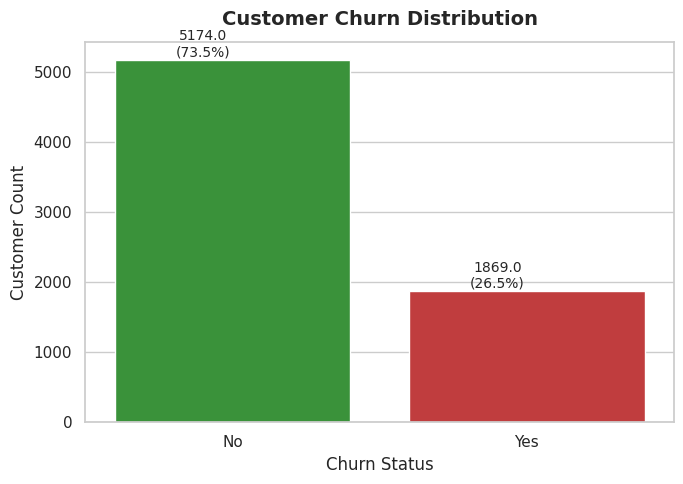

In [5]:
# 1. Churn Distribution Bar Chart
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Churn', data=df_clean, palette=['#2ca02c', '#d62728'], hue='Churn', legend=False)
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Customer Count', fontsize=12)
total = len(df_clean)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 50
    ax.annotate(f'{p.get_height()}\n({percentage})', (x, y), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

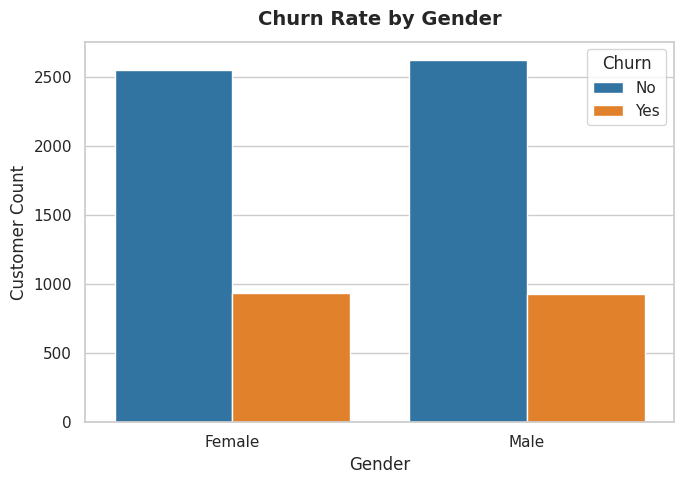

In [6]:
# 2. Gender vs Churn
plt.figure(figsize=(7, 5))
sns.countplot(x='gender', hue='Churn', data=df_clean, palette=['#1f77b4', '#ff7f0e'])
plt.title('Churn Rate by Gender', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Customer Count', fontsize=12)
plt.legend(title='Churn', frameon=True)
plt.tight_layout()
plt.show()

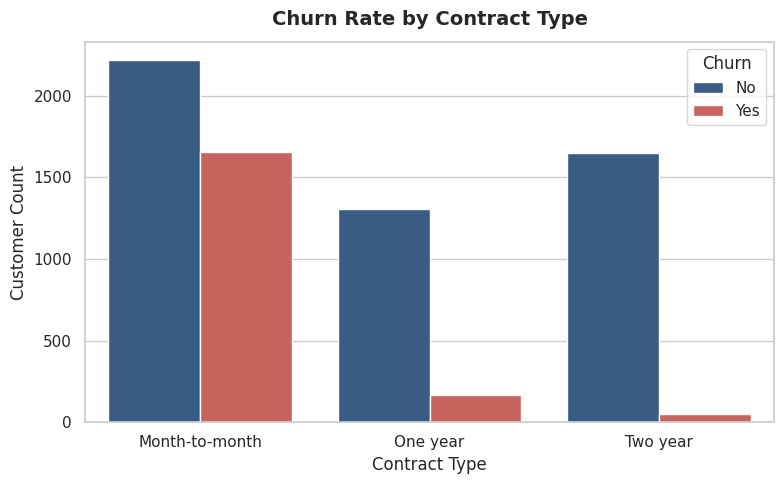

In [7]:
# 3. Contract Type vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df_clean, palette=['#2b5c8f', '#d9534f'])
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Customer Count', fontsize=12)
plt.legend(title='Churn', frameon=True)
plt.tight_layout()
plt.show()

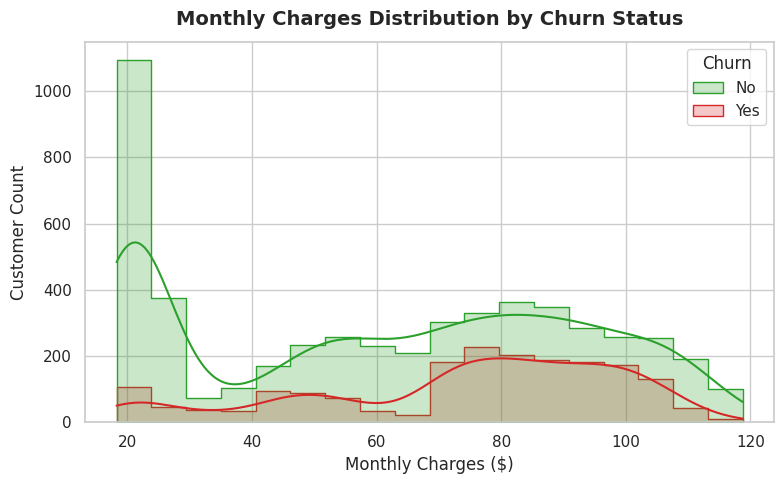

In [8]:
# 4. Monthly Charges Histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x='MonthlyCharges', hue='Churn', kde=True, element="step", palette=['#2ca02c', '#d62728'])
plt.title('Monthly Charges Distribution by Churn Status', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Monthly Charges ($)', fontsize=12)
plt.ylabel('Customer Count', fontsize=12)
plt.tight_layout()
plt.show()

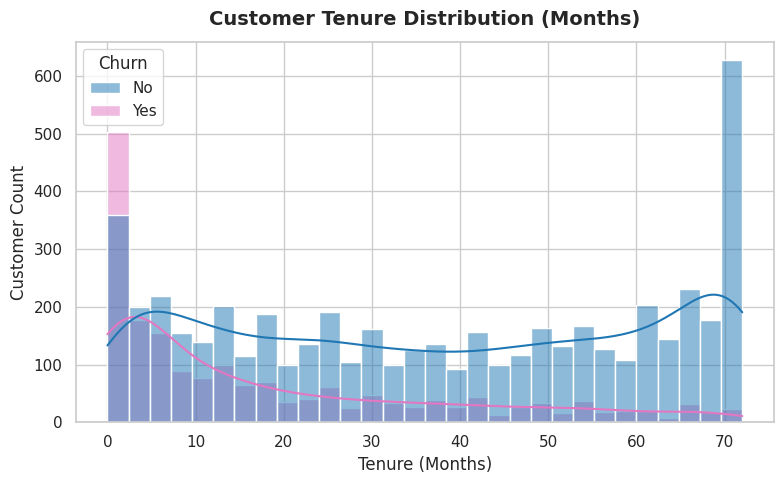

In [9]:
# 5. Tenure Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x='tenure', hue='Churn', kde=True, bins=30, palette=['#1f77b4', '#e377c2'])
plt.title('Customer Tenure Distribution (Months)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Customer Count', fontsize=12)
plt.tight_layout()
plt.show()

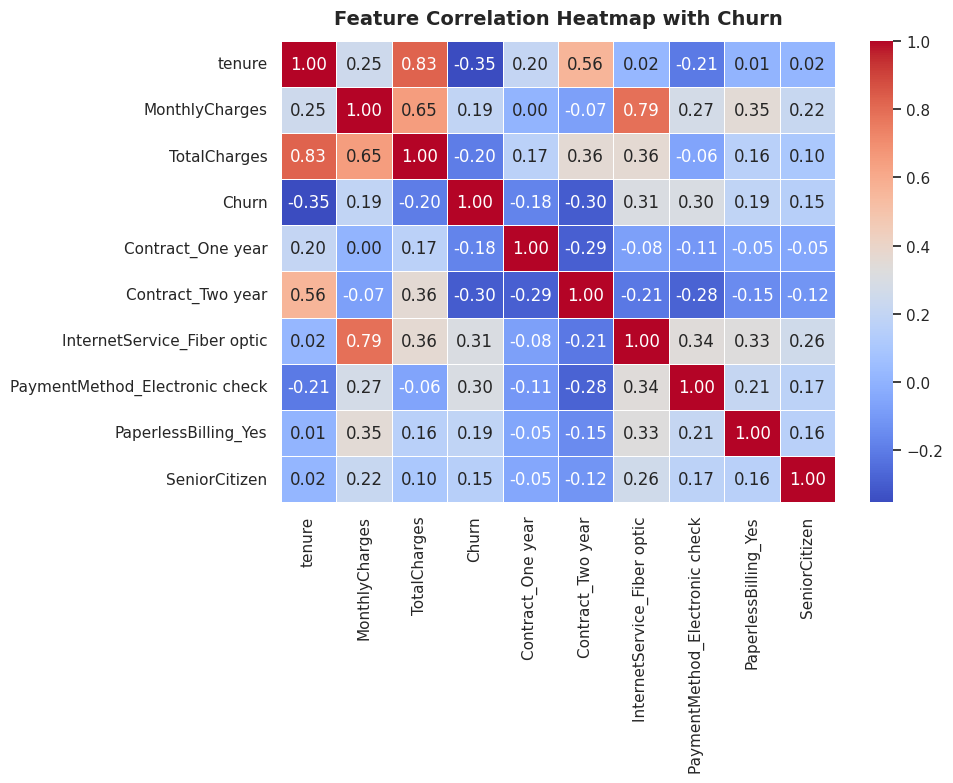

In [10]:
# 6. Correlation Heatmap
df_encoded_temp = pd.get_dummies(df_clean, drop_first=True)
df_encoded_temp['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 
             'Contract_One year', 'Contract_Two year', 
             'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 
             'PaperlessBilling_Yes', 'SeniorCitizen']
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded_temp[corr_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap with Churn', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

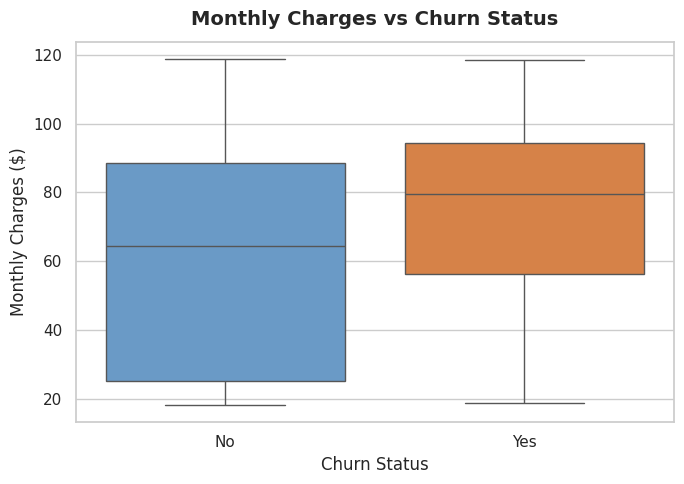

In [11]:
# 7. Boxplot of Monthly Charges vs Churn
plt.figure(figsize=(7, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean, palette=['#5b9bd5', '#ed7d31'], hue='Churn', legend=False)
plt.title('Monthly Charges vs Churn Status', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)
plt.tight_layout()
plt.show()

## Section 5: Feature Engineering & One-Hot Encoding
Categorical variables are encoded using One-Hot Encoding (`pd.get_dummies(drop_first=True)`), and target `Churn` is mapped to binary integer format (1 for Churn, 0 for Non-Churn).

In [12]:
# Binary mapping for Churn target
df_clean['Churn_Numeric'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# Select categorical columns
cat_cols = df_clean.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
if 'Churn' in cat_cols:
    cat_cols.remove('Churn')

# Apply One-Hot Encoding
df_final = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
df_final['Churn'] = df_clean['Churn_Numeric']
df_final = df_final.drop(columns=['Churn_Numeric'])

print("Final Encoded Data Shape:", df_final.shape)
df_final.head(3)

Final Encoded Data Shape: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True


## Section 6: Train/Test Split & Feature Scaling
We perform an **80% Training / 20% Testing** stratified split with `random_state=42`. Numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) are standardized using `StandardScaler`.

In [13]:
X = df_final.drop(columns=['Churn'])
y = df_final['Churn']

# Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (5634, 30), X_test shape: (1409, 30)


## Section 7: Supervised Learning Classifiers

We train and evaluate **4 supervised classification models**:
1. **Logistic Regression**
2. **Naive Bayes (GaussianNB)**
3. **Decision Tree Classifier** (`max_depth=5`)
4. **Random Forest Classifier** (`n_estimators=100`, `max_depth=8`)

=== Logistic Regression Metrics ===
Accuracy:  0.8055 | Precision: 0.6572 | Recall: 0.5588 | F1 Score: 0.6040
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



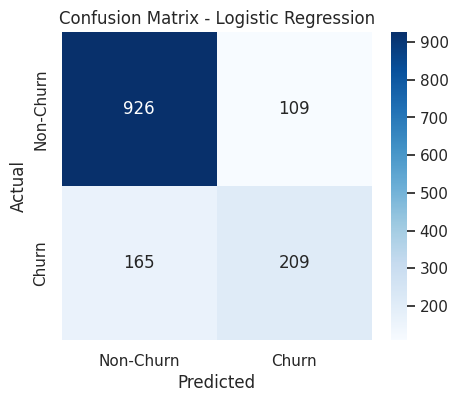

=== Naive Bayes Metrics ===
Accuracy:  0.6558 | Precision: 0.4269 | Recall: 0.8663 | F1 Score: 0.5719
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.58      0.71      1035
           1       0.43      0.87      0.57       374

    accuracy                           0.66      1409
   macro avg       0.67      0.72      0.64      1409
weighted avg       0.79      0.66      0.67      1409



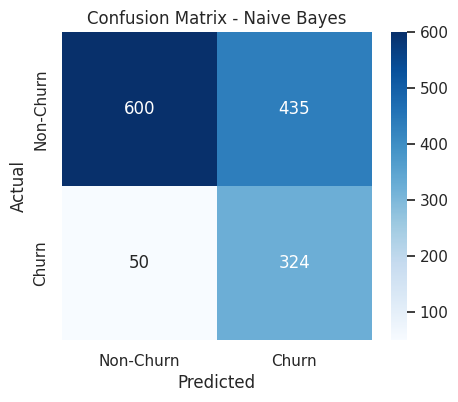

=== Decision Tree Metrics ===
Accuracy:  0.7942 | Precision: 0.6296 | Recall: 0.5455 | F1 Score: 0.5845
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



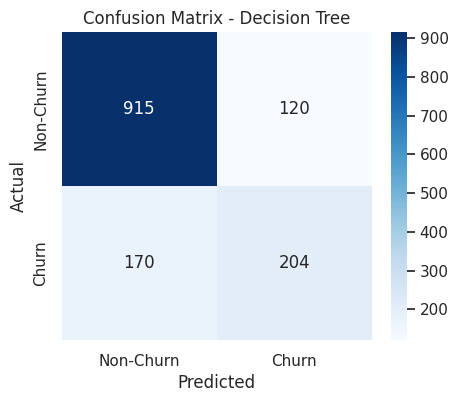

=== Random Forest Metrics ===
Accuracy:  0.8105 | Precision: 0.6890 | Recall: 0.5214 | F1 Score: 0.5936
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.88      1035
           1       0.69      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



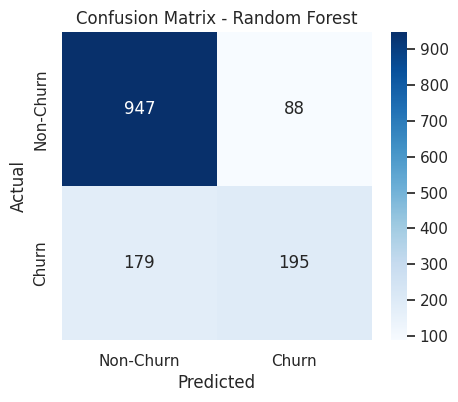

In [14]:
# Define classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
}

results = []

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

    print(f"=== {name} Metrics ===")
    print(f"Accuracy:  {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1 Score: {f1:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Churn', 'Churn'], yticklabels=['Non-Churn', 'Churn'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## Section 8: Model Performance Comparison & Evaluation Table
We aggregate all evaluation metrics across all four classifiers into a consolidated comparison matrix.

In [15]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046
1,Naive Bayes,0.655784,0.426877,0.866310,0.571933
2,Decision Tree,0.794180,0.629630,0.545455,0.584527
3,Random Forest,0.810504,0.689046,0.521390,0.593607


## Section 9: Unsupervised Learning (K-Means Clustering)
We apply K-Means Clustering on customer behavioral features. The **Elbow Method** identifies an optimal cluster hyperparameter of $K=3$.

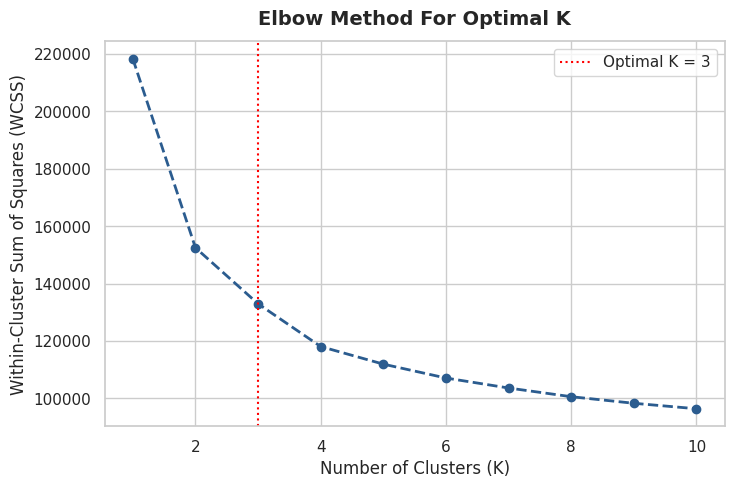

In [16]:
X_cluster = df_final.copy()
scaler_km = StandardScaler()
X_cluster_scaled = scaler_km.fit_transform(X_cluster)

# Elbow Method calculation
wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='#2b5c8f', linewidth=2)
plt.title('Elbow Method For Optimal K', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.axvline(x=3, color='red', linestyle=':', label='Optimal K = 3')
plt.legend()
plt.show()

In [17]:
# Fit Optimal K-Means (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

cluster_summary = df_clean.groupby('Cluster')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()
cluster_summary['Churn_Rate (%)'] = df_clean.groupby('Cluster')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
cluster_summary

,tenure,MonthlyCharges,TotalCharges,Churn_Rate (%)
Cluster,,,,
0,30.547182,21.079194,668.099443,7.404980
1,16.076115,67.702086,1075.907803,46.337580
2,55.067732,88.920993,4911.094100,12.663021


## Section 10: Dimensionality Reduction with PCA
Principal Component Analysis (PCA) reduces the 30-feature space to 2 principal component orthogonal axes for 2D cluster visual inspection.

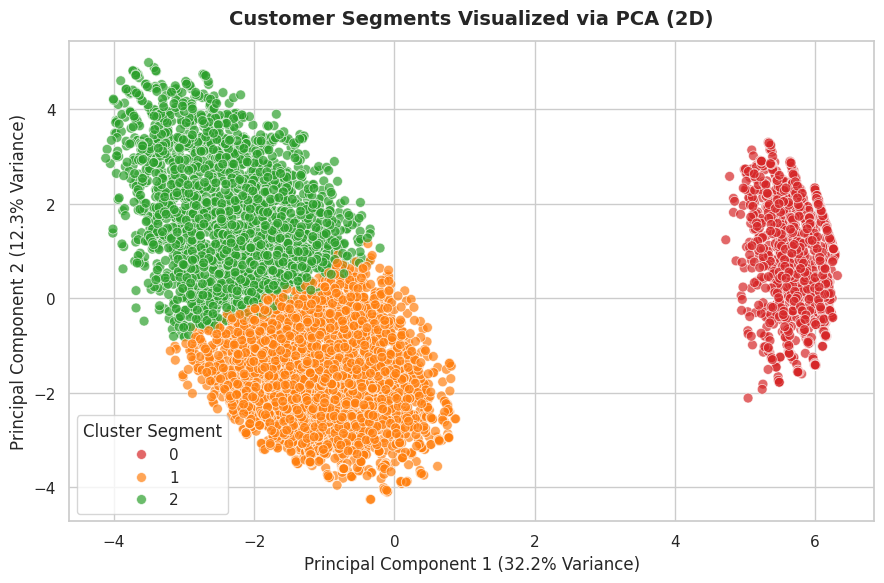

In [18]:
pca = PCA(n_components=2, random_state=42)
pca_transformed = pca.fit_transform(X_cluster_scaled)

df_clean['PCA1'] = pca_transformed[:, 0]
df_clean['PCA2'] = pca_transformed[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='PCA1', y='PCA2', hue='Cluster', data=df_clean,
    palette=['#d62728', '#ff7f0e', '#2ca02c'], alpha=0.7, s=50
)
plt.title('Customer Segments Visualized via PCA (2D)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(title='Cluster Segment')
plt.tight_layout()
plt.show()

## Section 11: High-Risk Customer Analysis & Retention Strategies

### Customer Cohort Breakdown:
* 🔴 **Cluster 1 (High-Risk - 46.34% Churn Rate)**: Short tenure (< 16 months), Month-to-month contracts, higher monthly charges ($67.70), Fiber optic internet, Electronic check payments.
* 🟡 **Cluster 2 (Medium-Risk - 12.66% Churn Rate)**: Long tenure (> 55 months), high monthly charges ($88.92), premium package subscribers.
* 🟢 **Cluster 0 (Loyal - 7.40% Churn Rate)**: Moderate tenure (~30 months), basic phone service users, lowest monthly charges ($21.08).

---

### Top 5 Strategic Retention Initiatives:
1. **Annual Contract Migration Campaign**: Target Month-to-month subscribers in Cluster 1 with a 15% bill discount upon upgrading to a 1-year or 2-year contract.
2. **Fiber Optic Support Bundling**: Provide free online security and tech support add-ons for high-cost fiber optic customers.
3. **Auto-Pay Conversion Rebate**: Offer a $15 one-time account credit for electronic check users switching to automatic credit card or bank debit payments.
4. **90-Day Onboarding Support**: Deploy dedicated check-ins for new subscribers during their first 12 months.
5. **VIP Loyalty Renewal Perks**: Grant proactive renewal perks to long-tenure customers 60 days prior to contract expiration.